In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading and Initial Exploration

In [2]:
# Load dataset
df = pd.read_csv("Student_Score.csv")
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [3]:
# Check info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


### 2. Data Cleaning

In [4]:
#  Drop unnecessary columns
df.drop("Unnamed: 0",axis = 1,inplace=True)
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [5]:
study_map = {
    '< 5': 2.5,
    '5 - 10': 7.5,
    '10 - 15': 12.5,
    '15 - 20': 17.5,
    '20 <': 22.5  
}
df['WeeklyStudyHours'] = df['WklyStudyHours'].map(study_map)

In [6]:
df.drop(columns='WklyStudyHours', axis=1, inplace=True)
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,MathScore,ReadingScore,WritingScore,WeeklyStudyHours
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,71,71,74,2.5
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,69,90,88,7.5
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,87,93,91,2.5
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,45,56,42,7.5
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,76,78,75,7.5


In [7]:
# Check null values
df.isnull().sum()

Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
MathScore                 0
ReadingScore              0
WritingScore              0
WeeklyStudyHours       6157
dtype: int64

In [8]:
# Fill missing values for each column based on appropriate strategies

# Define fill strategies for columns
fill_null_values = {
    'EthnicGroup': 'mode',
    'ParentEduc': 'mode',
    'TestPrep': 'mode',
    'ParentMaritalStatus': 'mode',
    'PracticeSport': 'mode',
    'IsFirstChild': 'mode',
    'NrSiblings': 'median',
    'TransportMeans': 'mode',
    'WeeklyStudyHours': 'mode'
}

# Apply fill strategies
for column, strategy in fill_null_values.items():
    if strategy == 'mode':
        df[column] = df[column].fillna(df[column].mode()[0])
    elif strategy == 'median':
        df[column] = df[column].fillna(df[column].median())

In [9]:
df.isnull().sum()

Gender                 0
EthnicGroup            0
ParentEduc             0
LunchType              0
TestPrep               0
ParentMaritalStatus    0
PracticeSport          0
IsFirstChild           0
NrSiblings             0
TransportMeans         0
MathScore              0
ReadingScore           0
WritingScore           0
WeeklyStudyHours       0
dtype: int64

### 3. Exploratory Data Analysis (EDA)

In [10]:
# List of categorical columns
columns = [
    'Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
    'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'TransportMeans'
]

# Display value counts for each column
for col in columns:
    print(f"\nValue counts for '{col}':")
    print(df[col].unique())


Value counts for 'Gender':
['female' 'male']

Value counts for 'EthnicGroup':
['group C' 'group B' 'group A' 'group D' 'group E']

Value counts for 'ParentEduc':
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

Value counts for 'LunchType':
['standard' 'free/reduced']

Value counts for 'TestPrep':
['none' 'completed']

Value counts for 'ParentMaritalStatus':
['married' 'single' 'widowed' 'divorced']

Value counts for 'PracticeSport':
['regularly' 'sometimes' 'never']

Value counts for 'IsFirstChild':
['yes' 'no']

Value counts for 'TransportMeans':
['school_bus' 'private']


In [11]:
# List of categorical columns
columns = [
    'Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep',
    'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'TransportMeans'
]

# Display value counts for each column
for col in columns:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())


Value counts for 'Gender':
Gender
female    15424
male      15217
Name: count, dtype: int64

Value counts for 'EthnicGroup':
EthnicGroup
group C    11052
group D     7503
group B     5826
group E     4041
group A     2219
Name: count, dtype: int64

Value counts for 'ParentEduc':
ParentEduc
some college          8478
high school           5687
associate's degree    5550
some high school      5517
bachelor's degree     3386
master's degree       2023
Name: count, dtype: int64

Value counts for 'LunchType':
LunchType
standard        19905
free/reduced    10736
Name: count, dtype: int64

Value counts for 'TestPrep':
TestPrep
none         20686
completed     9955
Name: count, dtype: int64

Value counts for 'ParentMaritalStatus':
ParentMaritalStatus
married     18034
single       7097
divorced     4919
widowed       591
Name: count, dtype: int64

Value counts for 'PracticeSport':
PracticeSport
sometimes    15844
regularly    10793
never         4004
Name: count, dtype: int64

Value counts f

In [12]:
# describe dataset
df.describe(include='all')

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,MathScore,ReadingScore,WritingScore,WeeklyStudyHours
count,30641,30641,30641,30641,30641,30641,30641,30641,30641.000000,30641,30641.000000,30641.000000,30641.000000,30641.000000
unique,2,5,6,2,2,4,3,2,NaN,2,NaN,NaN,NaN,NaN
top,female,group C,some college,standard,none,married,sometimes,yes,NaN,school_bus,NaN,NaN,NaN,NaN
freq,15424,11052,8478,19905,20686,18034,15844,19986,NaN,19279,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.138409,NaN,66.558402,69.377533,68.418622,6.155723
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.420707,NaN,15.361616,14.758952,15.443525,2.216859
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,10.000000,4.000000,2.500000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,56.000000,59.000000,58.000000,2.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,67.000000,70.000000,69.000000,7.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,78.000000,80.000000,79.000000,7.500000


#### 3.1 Gender Distribution

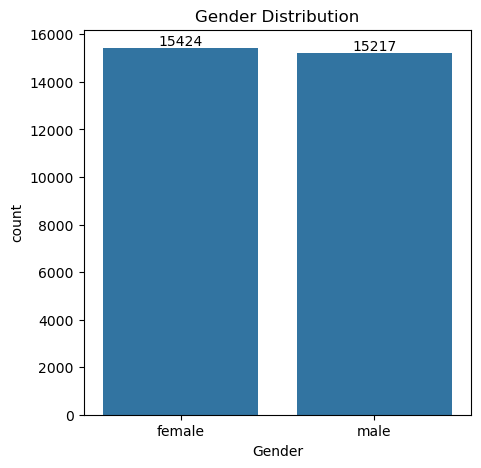

In [13]:
plt.figure(figsize = (5,5))
ax = sns.countplot(data = df, x = "Gender")
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.show()

Analysis Result :- From the above chart we have analysed tha the no. of 'Female' data is more than the 'Male' data

#### 3.2 Impact of Parent's Education

In [14]:
gb1 = df.groupby("ParentEduc").agg({'MathScore':'mean','ReadingScore':'mean','WritingScore':'mean'})
gb1

,MathScore,ReadingScore,WritingScore
ParentEduc,,,
associate's degree,68.365586,71.124324,70.299099
bachelor's degree,70.466627,73.062020,73.331069
high school,64.435731,67.213997,65.421136
master's degree,72.336134,75.832921,76.356896
some college,66.445978,69.189667,68.456711
some high school,62.584013,65.510785,63.632409


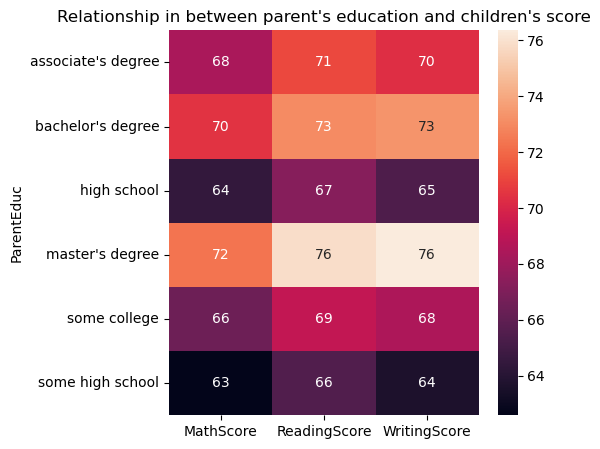

In [15]:
plt.figure(figsize = (5,5))
sns.heatmap(gb1,annot = True)
plt.title("Relationship in between parent's education and children's score")
plt.show()

Analysis Result :- The education of parents have good impact on their children.Parent's education level shows a positive correlation with students' scores across all subjects.

#### 3.3 Impact of Parent's Marital Status

In [16]:
# Analysis based upon marital status
gb2 = df.groupby("ParentMaritalStatus").agg({'MathScore':'mean','ReadingScore':'mean','WritingScore':'mean'})
gb2

,MathScore,ReadingScore,WritingScore
ParentMaritalStatus,,,
divorced,66.691197,69.655011,68.799146
married,66.650161,69.379561,68.406177
single,66.165704,69.157250,68.174440
widowed,67.368866,69.651438,68.563452


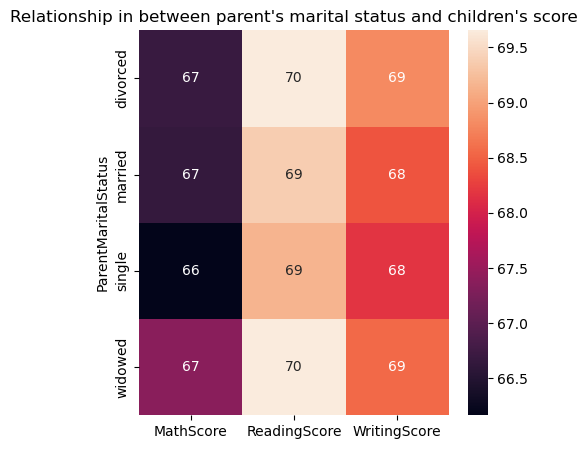

In [17]:
plt.figure(figsize = (5,5))
sns.heatmap(gb2,annot = True)
plt.title("Relationship in between parent's marital status and children's score")
plt.show()

Analysis Result :- The marital status of parent's have negligible impact on their children

#### 3.4 identifying Outliers

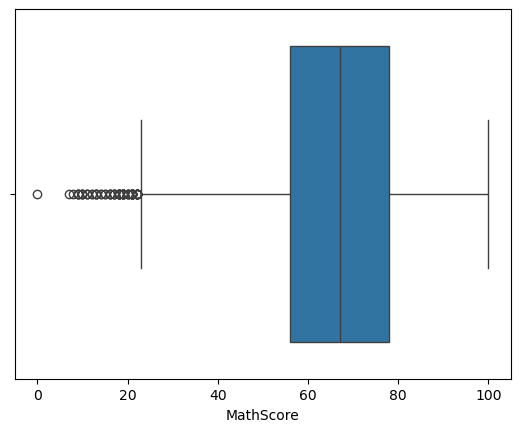

In [18]:
sns.boxplot(data =df,x="MathScore")
plt.show()

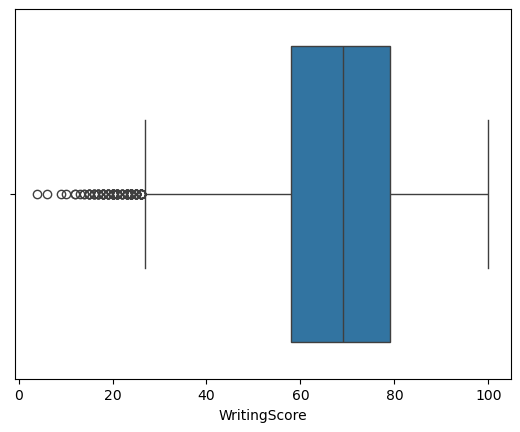

In [19]:
sns.boxplot(data =df,x="WritingScore")
plt.show()

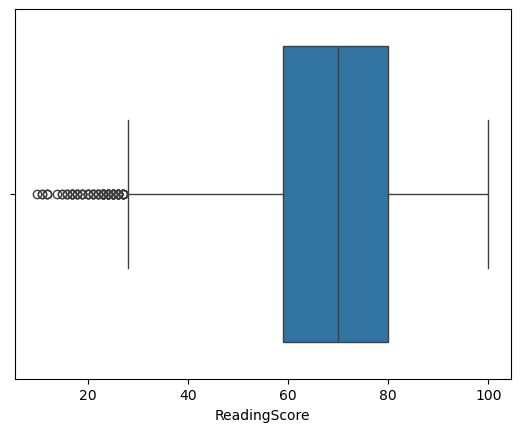

In [20]:
sns.boxplot(data = df , x = "ReadingScore") # or plt.boxplot(df["ReadingScore"])
plt.show()

Analysis Result:- Identified potential outliers in Math is more than Writing, and Reading scores.

#### 3.5 Distribution of Ethnic Groups

In [21]:
print(df["EthnicGroup"].unique())

['group C' 'group B' 'group A' 'group D' 'group E']


[2219, 5826, 11052, 7503, 4041]


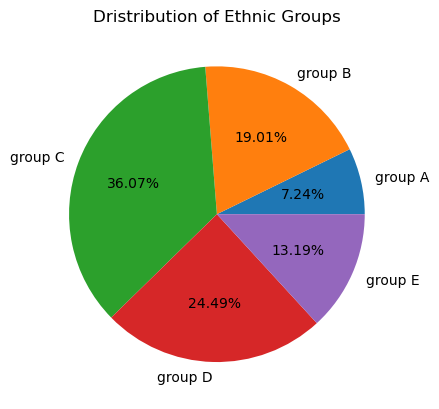

In [22]:
groupA = df.loc[(df["EthnicGroup"] == "group A")].count()
groupB = df.loc[(df["EthnicGroup"] == "group B")].count()
groupC = df.loc[(df["EthnicGroup"] == "group C")].count()
groupD = df.loc[(df["EthnicGroup"] == "group D")].count()
groupE = df.loc[(df["EthnicGroup"] == "group E")].count()

l = ['group A','group B','group C','group D','group E'] 
my_list = [groupA['EthnicGroup'],groupB['EthnicGroup'],groupC['EthnicGroup'],groupD['EthnicGroup'],groupE['EthnicGroup']]
print(my_list)
plt.pie(my_list, labels = l, autopct = '%1.2f%%')
plt.title("Dristribution of Ethnic Groups")
plt.show()

[Text(0, 0, '11052'),
 Text(0, 0, '5826'),
 Text(0, 0, '2219'),
 Text(0, 0, '7503'),
 Text(0, 0, '4041')]

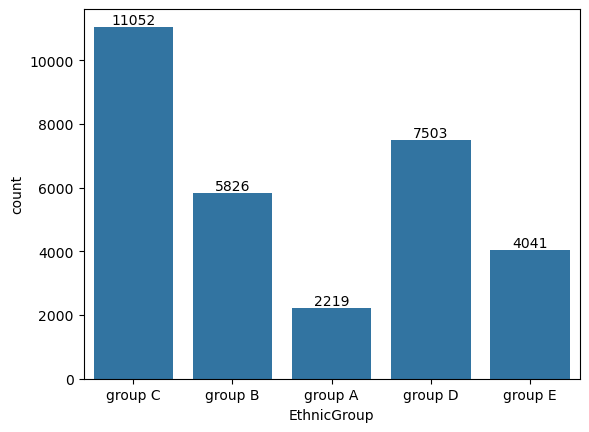

In [23]:
ax = sns.countplot(data =df , x = 'EthnicGroup')
ax.bar_label(ax.containers[0])

Analysis Result:- Visualized the distribution of students across different ethnic groups.

### 4.Prepare Data For Machine Learning Model

In [24]:
df['TotalScore'] = df[['MathScore', 'ReadingScore', 'WritingScore']].sum(axis=1)
df['AverageScore'] = df[['MathScore', 'ReadingScore', 'WritingScore']].mean(axis=1)

In [25]:
X = df.drop(['AverageScore'],axis=1)
y = df['AverageScore']

In [26]:
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,MathScore,ReadingScore,WritingScore,WeeklyStudyHours,TotalScore,AverageScore
0,female,group C,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,71,71,74,2.5,216,72.000000
1,female,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,69,90,88,7.5,247,82.333333
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,87,93,91,2.5,271,90.333333
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,school_bus,45,56,42,7.5,143,47.666667
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,76,78,75,7.5,229,76.333333


In [27]:
# Create column transformation with 3 types of transformers 
num_features = X.select_dtypes(exclude = "object").columns
onehot_columns = ['Gender','EthnicGroup','ParentEduc','LunchType','TestPrep','ParentMaritalStatus','PracticeSport','IsFirstChild','TransportMeans']

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer([
               ('OneHotEncoder',oh_transformer,onehot_columns),
                ('StandardScaler',numeric_transformer,num_features)],
                 remainder='passthrough')

In [28]:
X=preprocessor.fit_transform(X)
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.606462,0.289141,0.109933,0.361412,-1.649082,0.268562
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,-1.505198,0.158944,1.397308,1.267955,0.606398,0.983469
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.310349,1.330715,1.600578,1.462215,-1.649082,1.536945
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,-0.801311,-1.403417,-0.906416,-1.710688,0.606398,-1.414929
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,-1.505198,0.614633,0.584229,0.426165,0.606398,0.568361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,-0.097424,-0.492040,-0.567633,-0.221366,0.606398,-0.446346
30637,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,-0.801311,-0.557138,-1.109686,-1.127910,0.606398,-0.976761
30638,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,-0.801311,-0.361843,0.042176,-0.091860,0.606398,-0.146546
30639,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.606462,1.005223,1.397308,1.591721,0.606398,1.398576


### 5.Import Necessary ML Models

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
def evaluate_model(true,predicted):
    mse = mean_squared_error(true,predicted)
    rmse = root_mean_squared_error(true,predicted)
    mae = mean_absolute_error(true,predicted)
    r2 = r2_score(true,predicted)
    return mse,rmse,mae,r2

In [32]:
models = {"Random Forest Regressor ->":RandomForestRegressor(),
          "Linear Regression ->":LinearRegression(),
          "Ridge ->":Ridge(),
          "Lasso ->":Lasso(),
          "K Neighbors Regressor ->":KNeighborsRegressor(),
          "DecisionTreeRegressor ->":DecisionTreeRegressor(),
          
         }

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    # Make prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Set performance
    model_train_mse,model_train_rmse,model_train_mae,model_train_r2 = evaluate_model(y_train,y_train_pred)
    

    # Test set Performance
    model_test_mse,model_test_rmse,model_test_mae,model_test_r2 = evaluate_model(y_test,y_test_pred)


    print(list(models.keys())[i])

    print("Model Performance For Training Set",'\n')
    print("MSE: {:.2f}".format(model_train_mse * 100))
    print("RMSE: {:.2f}".format(model_train_rmse * 100))
    print("MAE: {:.2f}".format(model_train_mae * 100))
    print("R2 Score: {:.2f}%".format(model_train_r2 * 100))

    print("-"*50)

    print("Model Performance For Test Set",'\n')
    print("MSE: {:.2f}".format(model_test_mse * 100) )
    print("RMSE: {:.2f}".format(model_test_rmse * 100))
    print("MAE: {:.2f}".format(model_test_mae * 100))
    print("R2 Score: {:.2f}%".format(model_test_r2 * 100))

    print("="*50)

Random Forest Regressor ->
Model Performance For Training Set 

MSE: 0.01
RMSE: 1.11
MAE: 0.03
R2 Score: 100.00%
--------------------------------------------------
Model Performance For Test Set 

MSE: 0.18
RMSE: 4.20
MAE: 0.12
R2 Score: 100.00%
Linear Regression ->
Model Performance For Training Set 

MSE: 0.00
RMSE: 0.00
MAE: 0.00
R2 Score: 100.00%
--------------------------------------------------
Model Performance For Test Set 

MSE: 0.00
RMSE: 0.00
MAE: 0.00
R2 Score: 100.00%
Ridge ->
Model Performance For Training Set 

MSE: 0.00
RMSE: 0.02
MAE: 0.02
R2 Score: 100.00%
--------------------------------------------------
Model Performance For Test Set 

MSE: 0.00
RMSE: 0.02
MAE: 0.02
R2 Score: 100.00%
Lasso ->
Model Performance For Training Set 

MSE: 99.67
RMSE: 99.83
MAE: 80.98
R2 Score: 99.52%
--------------------------------------------------
Model Performance For Test Set 

MSE: 98.03
RMSE: 99.01
MAE: 79.99
R2 Score: 99.52%
K Neighbors Regressor ->
Model Performance For Trainin

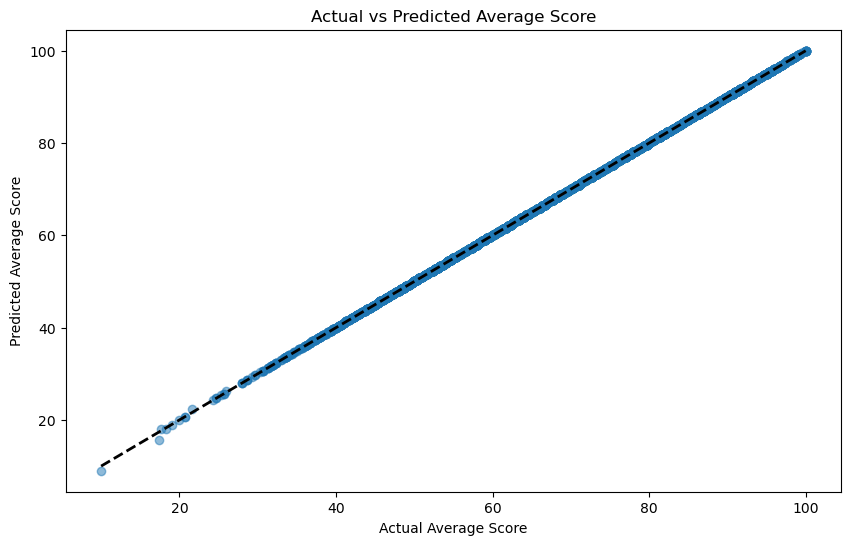

In [33]:
# Visualize the predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Average Score')
plt.ylabel('Predicted Average Score')
plt.title('Actual vs Predicted Average Score')
plt.show()

In [34]:
# Initialize few parameters for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# K Neighbors Regressor parameter grid
knn_params = {"n_neighbors":[2,3,10,20,40,50]}

# Random Forest Regressor parameter grid
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [35]:
# Model list for Hyperparameter Tuning
randomcv_models = [('K-Nearest Neighbors Regressor',KNeighborsRegressor(),knn_params),
                   ('Random Forest Regressor',RandomForestRegressor(),rf_params)]

In [177]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,param_distributions=params,
                                n_iter=100,cv=3,verbose=2,n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"-------------- Best Parameters for {model_name} ----------------")
    print(model_param[model_name])

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
-------------- Best Parameters for K-Nearest Neighbors Regressor ----------------
{'n_neighbors': 20}
-------------- Best Parameters for Random Forest Regressor ----------------
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}


In [37]:
models = {
          "KNN Regressor":KNeighborsRegressor(n_neighbors = 20),
          "Random Forest Regressor":RandomForestRegressor(n_estimators= 100, min_samples_split=2, 
                                                          min_samples_leaf=1, max_depth=None,bootstrap = True)        
         }

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    # Make prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Set performance
    model_train_mse,model_train_rmse,model_train_mae,model_train_r2 = evaluate_model(y_train,y_train_pred)
    

    # Test set Performance
    model_test_mse,model_test_rmse,model_test_mae,model_test_r2 = evaluate_model(y_test,y_test_pred)


    print(list(models.keys())[i])

    print("Model Performance For Training Set",'\n')
    print("MSE: {:.2f}".format(model_train_mse * 100))
    print("RMSE: {:.2f}".format(model_train_rmse * 100))
    print("MAE: {:.2f}".format(model_train_mae * 100))
    print("R2 Score: {:.2f}%".format(model_train_r2 * 100))

    print("-"*50)

    print("Model Performance For Test Set",'\n')
    print("MSE: {:.2f}".format(model_test_mse * 100) )
    print("RMSE: {:.2f}".format(model_test_rmse * 100))
    print("MAE: {:.2f}".format(model_test_mae * 100))
    print("R2 Score: {:.2f}%".format(model_test_r2 * 100))

    print("="*50)

KNN Regressor
Model Performance For Training Set 

MSE: 189.77
RMSE: 137.76
MAE: 106.03
R2 Score: 99.09%
--------------------------------------------------
Model Performance For Test Set 

MSE: 208.26
RMSE: 144.31
MAE: 110.63
R2 Score: 98.99%
Random Forest Regressor
Model Performance For Training Set 

MSE: 0.01
RMSE: 1.16
MAE: 0.03
R2 Score: 100.00%
--------------------------------------------------
Model Performance For Test Set 

MSE: 0.16
RMSE: 4.00
MAE: 0.11
R2 Score: 100.00%


In [38]:
# Save the model
import joblib
joblib.dump(model, 'student_score_model.pkl')
# Load the model
loaded_model = joblib.load('student_score_model.pkl')
# Make predictions with the loaded model
new_predictions = loaded_model.predict(X_test)
# Display the first few predictions
print("First few predictions from the loaded model:")
for pred in new_predictions[:5]:
    print("{:.2f}%".format(pred))

First few predictions from the loaded model:
81.33%
85.67%
83.67%
55.67%
50.67%
